<a href="https://colab.research.google.com/github/IttisafTazwar/Group13-AcousticSignalProcessingProject/blob/Rafid_EDA-and-Classification_IEEE/EDA_%26_classification_IEEE_DS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
import os

dataset_path = "/content/drive/MyDrive/kaiyuan_dataset/extracted"

print("Path exists:", os.path.exists(dataset_path))

Path exists: True


In [13]:
import os

dataset_path = "/content/drive/MyDrive/kaiyuan_dataset/extracted"

file_paths = []

# Walk through all folders and subfolders
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".wav"):   # keep only audio files
            file_paths.append(os.path.join(root, file))

print("Total .wav files found:", len(file_paths))

# Show a few sample paths
for i in range(5):
    print(file_paths[i])

Total .wav files found: 12918
/content/drive/MyDrive/kaiyuan_dataset/extracted/kaiyuan_target_002/20220626160835_M_QianDao_F_W&SpeedBoat_F_W&SpeedBoat_F_W&KaiYuan_F_W_1_label__1__18.wav
/content/drive/MyDrive/kaiyuan_dataset/extracted/kaiyuan_target_002/20220626160835_M_QianDao_F_W&SpeedBoat_F_W&SpeedBoat_F_W&KaiYuan_F_W_1_label__1__1.wav
/content/drive/MyDrive/kaiyuan_dataset/extracted/kaiyuan_target_002/20220626155833_M_QianDao_M_M&KaiYuan_M_W&SpeedBoat_F_W_1_label__1__11.wav
/content/drive/MyDrive/kaiyuan_dataset/extracted/kaiyuan_target_002/20220626155833_M_QianDao_M_M&KaiYuan_M_W&SpeedBoat_F_W_1_label__1__21.wav
/content/drive/MyDrive/kaiyuan_dataset/extracted/kaiyuan_target_002/20220626155333_M_WorkShip_N_S&KaiYuan_F_W&SpeedBoat_F_W_0_label__1__5.wav


In [14]:
import librosa
import numpy as np

clean_file_paths = []

for i, file in enumerate(file_paths):
    try:
        signal, sr = librosa.load(file, sr=None)

        # Condition 1: Minimum length check (~0.5 sec)
        if len(signal) < sr * 0.5:
            continue

        # Condition 2: Remove near-silent audio
        if np.mean(np.abs(signal)) < 0.001:
            continue

        clean_file_paths.append(file)

        # Progress update
        if i % 2000 == 0:
            print(f"Processed {i} files")

    except:
        # Skip corrupted files
        continue

print("\nOriginal files:", len(file_paths))
print("Clean files:", len(clean_file_paths))

Processed 0 files
Processed 2000 files
Processed 4000 files
Processed 6000 files
Processed 8000 files
Processed 10000 files
Processed 12000 files

Original files: 12918
Clean files: 12784


In [15]:
import pandas as pd

# Create DataFrame
df = pd.DataFrame({"file_path": clean_file_paths})

# Extract filename
df["file_name"] = df["file_path"].apply(lambda x: x.split("/")[-1])

# Check duplicate filenames
duplicate_names = df[df.duplicated(subset="file_name", keep=False)]

print("Total clean files:", len(df))
print("Duplicate filenames found:", len(duplicate_names))

Total clean files: 12784
Duplicate filenames found: 8307


In [16]:
import re

def extract_ship_info(filename):
    # Extract patterns like: SpeedBoat_F_W
    pattern = r'(SpeedBoat|KaiYuan|UUV|WorkShip|QianDao)_([NMF])_([WS])'

    matches = re.findall(pattern, filename)

    ships = []

    for match in matches:
        ship, distance, condition = match
        ships.append({
            "ship": ship,
            "distance": distance,
            "condition": condition
        })

    return ships


# Test on one file
sample_file = df['file_name'].iloc[0]
print("Filename:", sample_file)
print("Extracted:", extract_ship_info(sample_file))

Filename: 20220626160835_M_QianDao_F_W&SpeedBoat_F_W&SpeedBoat_F_W&KaiYuan_F_W_1_label__1__18.wav
Extracted: [{'ship': 'QianDao', 'distance': 'F', 'condition': 'W'}, {'ship': 'SpeedBoat', 'distance': 'F', 'condition': 'W'}, {'ship': 'SpeedBoat', 'distance': 'F', 'condition': 'W'}, {'ship': 'KaiYuan', 'distance': 'F', 'condition': 'W'}]


In [17]:
def get_dominant_ship(ship_info):

    # Score mappings
    distance_score = {'N': 3, 'M': 2, 'F': 1}
    condition_score = {'S': 3, 'W': 1}

    ship_scores = {}

    for item in ship_info:
        ship = item['ship']
        d = item['distance']
        c = item['condition']

        score = distance_score[d] + condition_score[c]

        if ship in ship_scores:
            ship_scores[ship] += score
        else:
            ship_scores[ship] = score

    # Get ship with highest score
    dominant_ship = max(ship_scores, key=ship_scores.get)

    return dominant_ship, ship_scores


# Test on your sample
sample_file = df['file_name'].iloc[0]
ship_info = extract_ship_info(sample_file)

dominant, scores = get_dominant_ship(ship_info)

print("Ship scores:", scores)
print("Dominant ship:", dominant)

Ship scores: {'QianDao': 2, 'SpeedBoat': 4, 'KaiYuan': 2}
Dominant ship: SpeedBoat


In [18]:
target_ships = ["UUV", "KaiYuan", "SpeedBoat" ]

data = []

for file in clean_file_paths:
    file_name = file.split("/")[-1]

    # Extract ship info
    ship_info = extract_ship_info(file_name)

    if len(ship_info) == 0:
        continue

    # Get dominant ship
    dominant_ship, scores = get_dominant_ship(ship_info)

    # Keep only selected ships
    if dominant_ship not in target_ships:
        continue

    data.append({
        "file_path": file,
        "file_name": file_name,
        "dominant_ship": dominant_ship,
        "num_ships": len(ship_info)
    })

df_final = pd.DataFrame(data)

print("Filtered dataset size:", len(df_final))
df_final.head()

Filtered dataset size: 7329


,file_path,file_name,dominant_ship,num_ships
0,/content/drive/MyDrive/kaiyuan_dataset/extract...,20220626160835_M_QianDao_F_W&SpeedBoat_F_W&Spe...,SpeedBoat,4
1,/content/drive/MyDrive/kaiyuan_dataset/extract...,20220626160835_M_QianDao_F_W&SpeedBoat_F_W&Spe...,SpeedBoat,4
2,/content/drive/MyDrive/kaiyuan_dataset/extract...,20220626155833_M_QianDao_M_M&KaiYuan_M_W&Speed...,KaiYuan,2
3,/content/drive/MyDrive/kaiyuan_dataset/extract...,20220626155833_M_QianDao_M_M&KaiYuan_M_W&Speed...,KaiYuan,2
4,/content/drive/MyDrive/kaiyuan_dataset/extract...,20220626155833_M_QianDao_M_M&KaiYuan_M_W&Speed...,SpeedBoat,3


dominant_ship
SpeedBoat    6152
UUV           708
KaiYuan       469
Name: count, dtype: int64


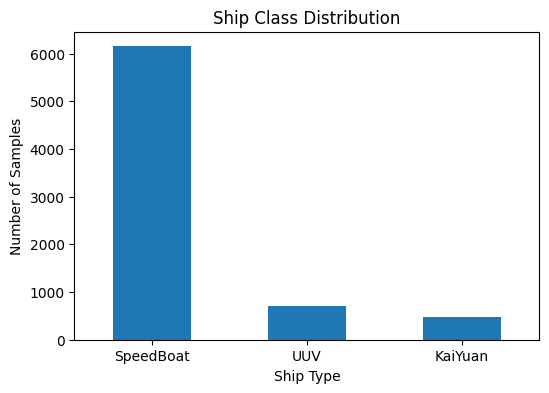

In [19]:
import matplotlib.pyplot as plt

class_counts = df_final['dominant_ship'].value_counts()

print(class_counts)

plt.figure(figsize=(6,4))
class_counts.plot(kind='bar')

plt.title("Ship Class Distribution")
plt.xlabel("Ship Type")
plt.ylabel("Number of Samples")

plt.xticks(rotation=0)
plt.show()

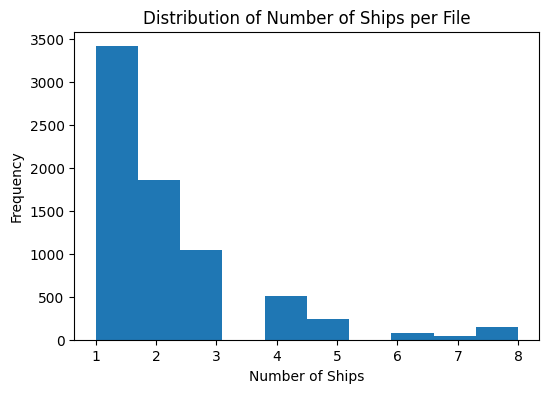

In [20]:
plt.figure(figsize=(6,4))

plt.hist(df_final['num_ships'], bins=10)

plt.title("Distribution of Number of Ships per File")
plt.xlabel("Number of Ships")
plt.ylabel("Frequency")

plt.show()

In [21]:
percentages = class_counts / len(df_final) * 100

print("Class percentage:")
print(percentages)

Class percentage:
dominant_ship
SpeedBoat    83.940510
UUV           9.660254
KaiYuan       6.399236
Name: count, dtype: float64


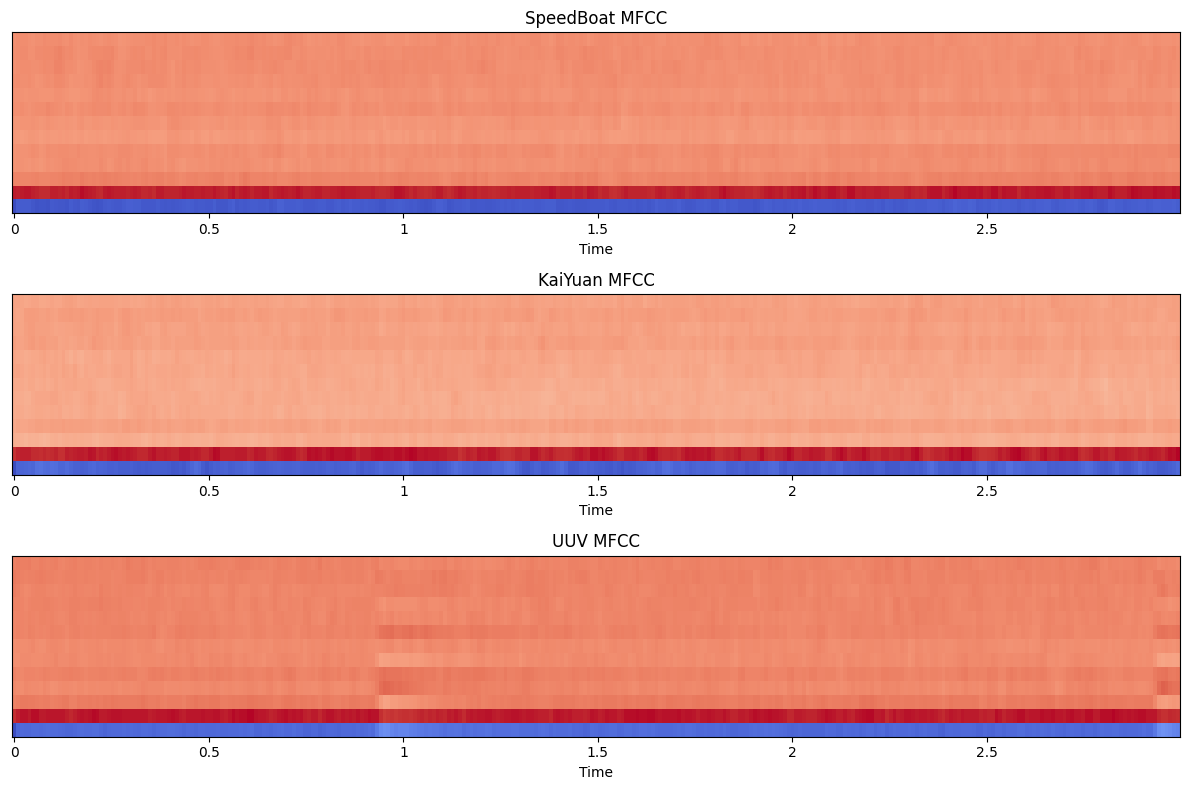

In [22]:
import librosa.display
import numpy as np

# Pick 1 sample per class
samples = {}

for _, row in df_final.iterrows():
    ship = row['dominant_ship']

    if ship not in samples:
        samples[ship] = row['file_path']

    if len(samples) == 3:
        break

# Plot MFCC
plt.figure(figsize=(12,8))

for i, (ship, file_path) in enumerate(samples.items()):
    signal, sr = librosa.load(file_path, sr=None)

    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)

    plt.subplot(3,1,i+1)
    librosa.display.specshow(mfcc, sr=sr, x_axis='time')
    plt.title(f"{ship} MFCC")

plt.tight_layout()
plt.show()

In [23]:
import numpy as np
import pandas as pd
import librosa

mfcc_eda_data = []

for i, row in df_final.iterrows():
    try:
        signal, sr = librosa.load(row['file_path'], sr=None)

        mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)

        mfcc_mean = np.mean(mfcc, axis=1)
        mfcc_std = np.std(mfcc, axis=1)

        record = {
            "dominant_ship": row["dominant_ship"]
        }

        for j in range(13):
            record[f"mfcc_{j+1}_mean"] = mfcc_mean[j]
            record[f"mfcc_{j+1}_std"] = mfcc_std[j]

        mfcc_eda_data.append(record)

        if i % 1000 == 0:
            print(f"Processed {i} samples")

    except:
        continue

mfcc_eda_df = pd.DataFrame(mfcc_eda_data)

print("MFCC EDA DataFrame shape:", mfcc_eda_df.shape)
mfcc_eda_df.head()

Processed 0 samples
Processed 1000 samples
Processed 2000 samples
Processed 3000 samples
Processed 4000 samples
Processed 5000 samples
Processed 6000 samples
Processed 7000 samples
MFCC EDA DataFrame shape: (7329, 27)


,dominant_ship,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,mfcc_4_std,mfcc_5_mean,...,mfcc_9_mean,mfcc_9_std,mfcc_10_mean,mfcc_10_std,mfcc_11_mean,mfcc_11_std,mfcc_12_mean,mfcc_12_std,mfcc_13_mean,mfcc_13_std
0,SpeedBoat,-477.605988,4.801576,130.750916,4.595085,16.218243,4.164029,-0.233684,4.619259,3.403615,...,-4.601301,3.969089,0.934938,4.163692,3.176429,4.550987,3.266874,4.182786,0.237317,3.986445
1,SpeedBoat,-483.983429,4.727220,129.879349,4.615144,17.600279,4.279862,-9.468925,4.045271,-4.421011,...,-4.435925,3.956797,2.741579,4.032904,4.424793,3.947500,6.952454,3.629478,5.098898,3.961185
2,KaiYuan,-371.970459,7.437091,138.697861,5.676955,-14.054471,4.414678,2.979481,4.031611,-12.011502,...,-4.175200,4.415781,6.559320,4.268025,2.878717,4.113534,8.287242,3.972004,3.053706,4.075099
3,KaiYuan,-369.277679,9.320217,131.805222,6.156863,-28.733755,4.495502,3.729367,4.681449,-11.938681,...,-2.880393,3.813265,5.917804,4.373290,3.244307,4.146041,10.117572,3.756042,6.186931,3.866021
4,SpeedBoat,-354.725525,6.060559,147.851517,4.931581,-30.071728,4.435901,9.514514,4.865074,-9.078482,...,-3.954763,4.556969,6.078681,3.960325,0.621674,4.775411,2.723279,4.904961,0.729789,4.268736


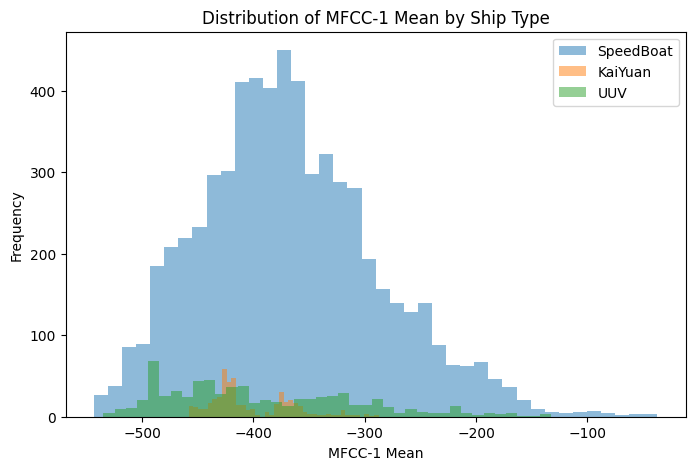

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

for ship in mfcc_eda_df["dominant_ship"].unique():
    subset = mfcc_eda_df[mfcc_eda_df["dominant_ship"] == ship]
    plt.hist(subset["mfcc_1_mean"], bins=40, alpha=0.5, label=ship)

plt.title("Distribution of MFCC-1 Mean by Ship Type")
plt.xlabel("MFCC-1 Mean")
plt.ylabel("Frequency")
plt.legend()
plt.show()

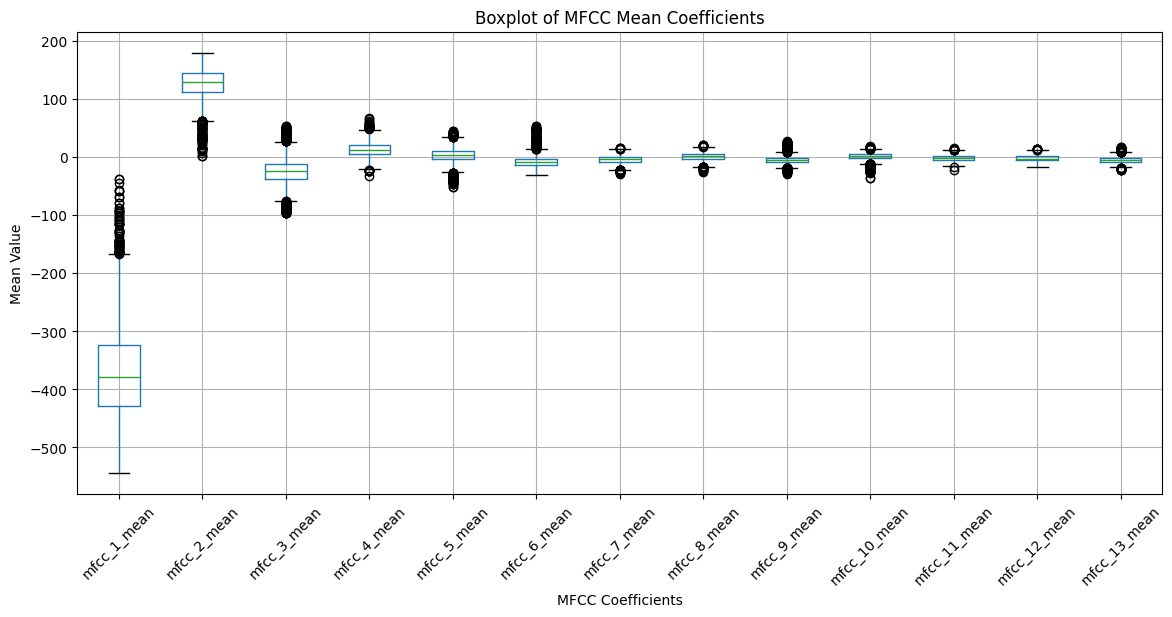

In [25]:
mfcc_mean_cols = [f"mfcc_{i}_mean" for i in range(1, 14)]

plt.figure(figsize=(14,6))
mfcc_eda_df[mfcc_mean_cols].boxplot()

plt.title("Boxplot of MFCC Mean Coefficients")
plt.xlabel("MFCC Coefficients")
plt.ylabel("Mean Value")
plt.xticks(rotation=45)
plt.show()

In [26]:
#Build Full MFCC Dataset (with Padding)
import numpy as np
import librosa
from sklearn.preprocessing import StandardScaler

max_len = 130

X = []
y = []

label_map = {
    "SpeedBoat": 0,
    "UUV": 1,
    "KaiYuan": 2
}

for i, row in df_final.iterrows():
    try:
        signal, sr = librosa.load(row['file_path'], sr=None)

        mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)

        # Padding / truncating
        if mfcc.shape[1] < max_len:
            pad_width = max_len - mfcc.shape[1]
            mfcc = np.pad(mfcc, ((0,0),(0,pad_width)), mode='constant')
        else:
            mfcc = mfcc[:, :max_len]

        X.append(mfcc)
        y.append(label_map[row['dominant_ship']])

        if i % 1000 == 0:
            print(f"Processed {i} samples")

    except:
        continue

X = np.array(X)
y = np.array(y)

# Normalize MFCC
scaler = StandardScaler()
X_reshaped = X.reshape(-1, X.shape[-1])
X_scaled = scaler.fit_transform(X_reshaped)
X = X_scaled.reshape(X.shape)

print("X shape:", X.shape)
print("y shape:", y.shape)

Processed 0 samples
Processed 1000 samples
Processed 2000 samples
Processed 3000 samples
Processed 4000 samples
Processed 5000 samples
Processed 6000 samples
Processed 7000 samples
X shape: (7329, 13, 130)
y shape: (7329,)


In [27]:
#STEP 10.1 — Train / Val / Test Split
from sklearn.model_selection import train_test_split

# First split: Train (70%) + Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

# Second split: Validation (15%) + Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (5130, 13, 130)
Validation shape: (1099, 13, 130)
Test shape: (1100, 13, 130)


In [28]:
#STEP 10.2 — Add Channel Dimension (CNN Requirement)
# Add channel dimension (for CNN)
X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("Updated shape:", X_train.shape)

Updated shape: (5130, 13, 130, 1)


In [29]:
#STEP 10.3 — Handle Class Imbalance (VERY IMPORTANT)
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print("Class weights:", class_weights)

Class weights: {0: np.float64(0.3971202972596377), 1: np.float64(3.4475806451612905), 2: np.float64(5.213414634146342)}


In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dense, Flatten
from tensorflow.keras.layers import Dropout, BatchNormalization

model = Sequential()

model.add(Input(shape=(13, 130, 1)))

# Block 1
model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(1,2)))

# Block 2
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(1,2)))

# Block 3
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(1,2)))

# Classification head
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(3, activation='softmax'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 13, 130, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 13, 130, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 65, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 65, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 13, 65, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 13, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 13, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 13, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 26624)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,408,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,501,955 (13.36 MB)

 Trainable params: 3,501,507 (13.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [31]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [32]:
history = model.fit(
    X_train, y_train,
    epochs=25,
    batch_size=32,
    validation_data=(X_val, y_val),
    class_weight=class_weights
)

Epoch 1/25
161/161 ━━━━━━━━━━━━━━━━━━━━ 79s 457ms/step - accuracy: 0.5536 - loss: 1.5543 - val_accuracy: 0.0965 - val_loss: 2.3753
Epoch 2/25
161/161 ━━━━━━━━━━━━━━━━━━━━ 81s 457ms/step - accuracy: 0.6386 - loss: 0.7232 - val_accuracy: 0.8490 - val_loss: 0.9990
Epoch 3/25
161/161 ━━━━━━━━━━━━━━━━━━━━ 83s 462ms/step - accuracy: 0.5928 - loss: 0.8323 - val_accuracy: 0.7843 - val_loss: 0.7991
Epoch 4/25
161/161 ━━━━━━━━━━━━━━━━━━━━ 77s 481ms/step - accuracy: 0.7593 - loss: 0.6870 - val_accuracy: 0.6833 - val_loss: 0.8277
Epoch 5/25
161/161 ━━━━━━━━━━━━━━━━━━━━ 73s 453ms/step - accuracy: 0.6782 - loss: 0.6042 - val_accuracy: 0.7480 - val_loss: 0.4507
Epoch 6/25
161/161 ━━━━━━━━━━━━━━━━━━━━ 76s 416ms/step - accuracy: 0.6998 - loss: 0.5643 - val_accuracy: 0.5787 - val_loss: 0.7487
Epoch 7/25
161/161 ━━━━━━━━━━━━━━━━━━━━ 74s 457ms/step - accuracy: 0.7322 - loss: 0.4817 - val_accuracy: 0.7707 - val_loss: 0.5618
Epoch 8/25
161/161 ━━━━━━━━━━━━━━━━━━━━ 80s 497ms/step - accuracy: 0.7481 - loss: 0

In [33]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_acc)

35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 130ms/step - accuracy: 0.9409 - loss: 0.2238
Test Accuracy: 0.9409090876579285


In [35]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred_classes))

cm = confusion_matrix(y_test, y_pred_classes)
print(cm)

35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step
              precision    recall  f1-score   support

           0       0.98      0.95      0.96       923
           1       0.91      0.96      0.94       106
           2       0.60      0.82      0.69        71

    accuracy                           0.94      1100
   macro avg       0.83      0.91      0.86      1100
weighted avg       0.95      0.94      0.94      1100

[[875  10  38]
 [  4 102   0]
 [ 13   0  58]]


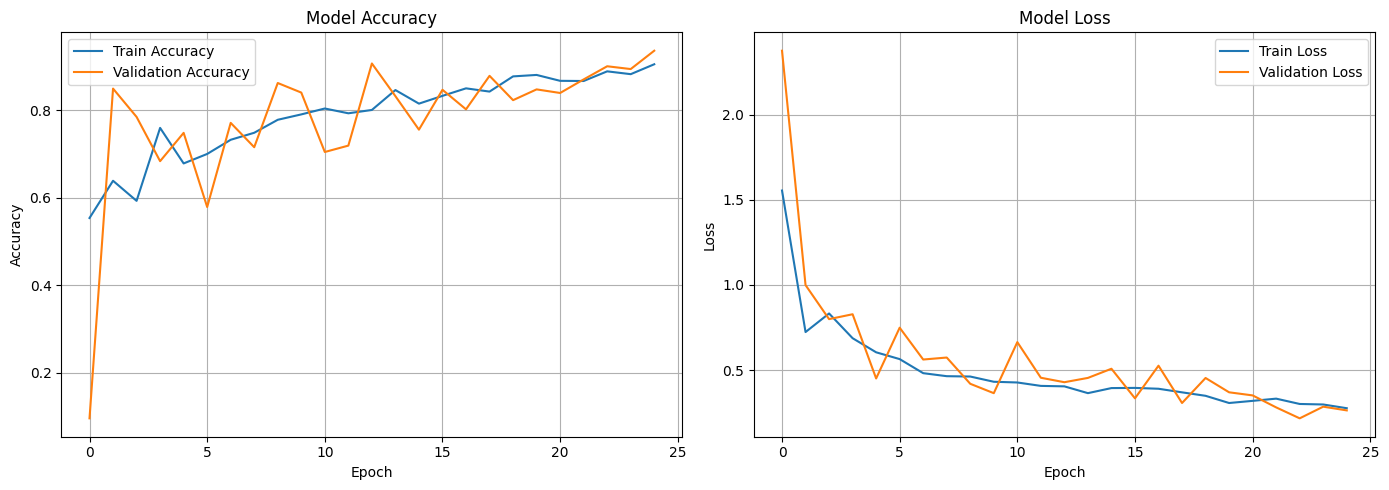

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

# 🔹 Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

# 🔹 Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step


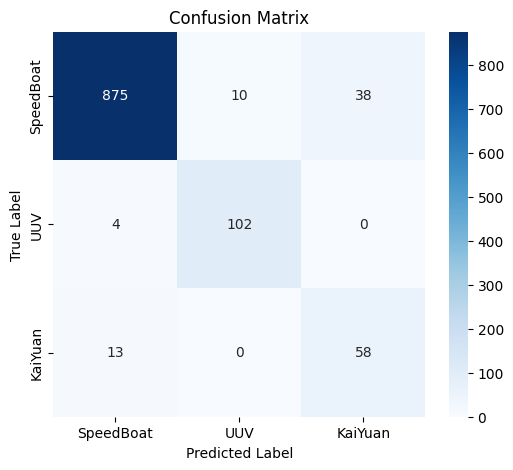

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predict
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

# Class labels
labels = ["SpeedBoat", "UUV", "KaiYuan"]

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

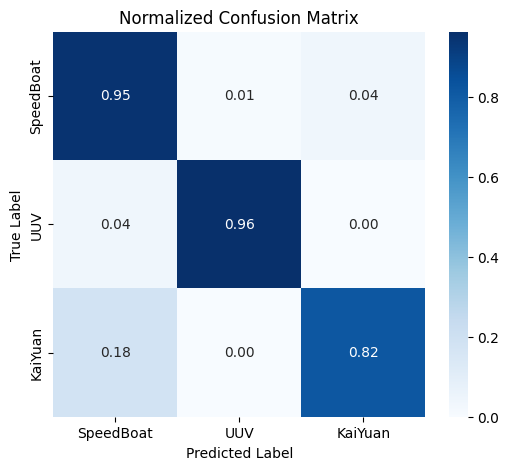

In [40]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_classes)

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

labels = ["SpeedBoat", "UUV", "KaiYuan"]

plt.figure(figsize=(6,5))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=labels, yticklabels=labels)

plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

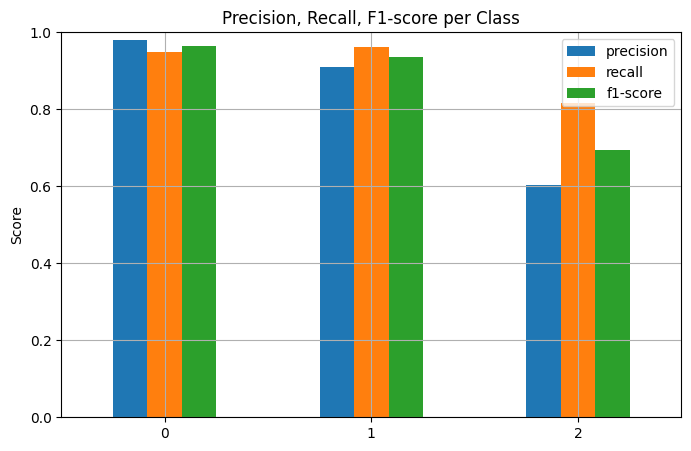

In [41]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred_classes, output_dict=True)
df_report = pd.DataFrame(report).transpose()

# Only classes
df_plot = df_report.iloc[:3][["precision", "recall", "f1-score"]]

df_plot.plot(kind='bar', figsize=(8,5))

plt.title("Precision, Recall, F1-score per Class")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0,1)
plt.grid()

plt.show()

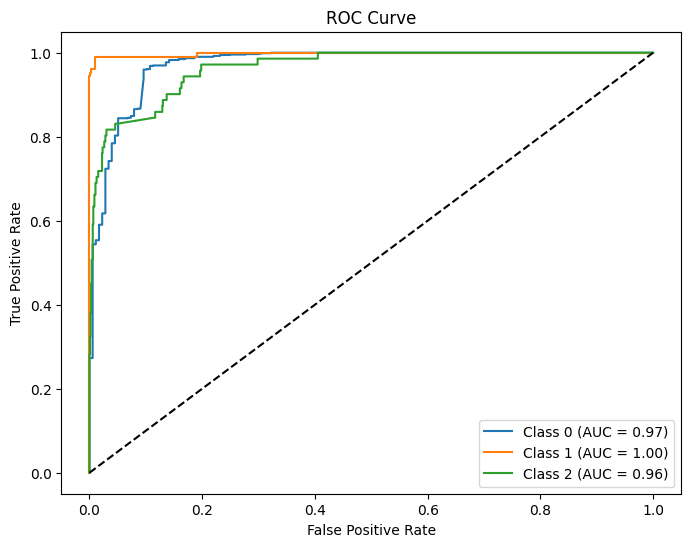

In [42]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0,1,2])

plt.figure(figsize=(8,6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

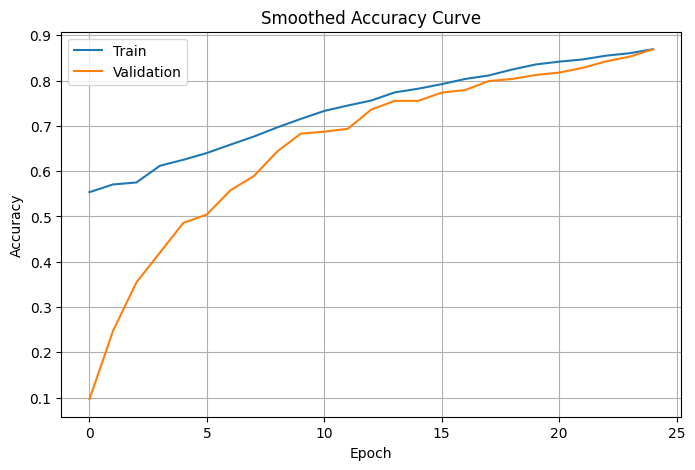

In [43]:
def smooth_curve(points, factor=0.8):
    smoothed = []
    for p in points:
        if smoothed:
            smoothed.append(smoothed[-1]*factor + p*(1-factor))
        else:
            smoothed.append(p)
    return smoothed

plt.figure(figsize=(8,5))

plt.plot(smooth_curve(history.history['accuracy']), label='Train')
plt.plot(smooth_curve(history.history['val_accuracy']), label='Validation')

plt.title("Smoothed Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid()

plt.show()

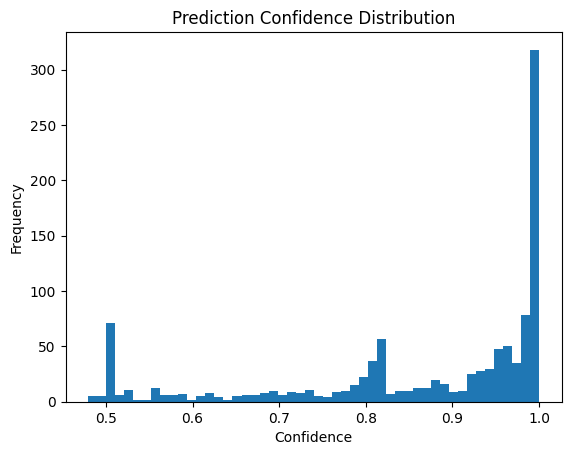

In [45]:
confidence = np.max(y_pred, axis=1)

plt.hist(confidence, bins=50)

plt.title("Prediction Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Frequency")

plt.show()